# 90 — Liquidation Cascade Scalper

**Hypothesis**: Long liquidation cascades overshoot — buying the bounce after a spike yields short-term profits.

## Strategy
- **Resolution**: Hourly
- **Entry**: Long liquidation volume > 2σ above rolling mean (cascade detected)
- **Exit**: Fixed target (+2%, +3%, +5%) OR stop loss (-2%, -3%) OR time stop (24h, 48h, 72h)
- **Risk**: High — mean-reversion fails during sustained crashes
- **Period**: 2020-02-02 → present (derivatives data availability)

In [1]:
import pandas as pd
import numpy as np
import vectorbt as vbt
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('.').resolve().parent
BL_HOURLY = PROJECT_ROOT / 'data' / 'bl' / 'hourly'
GN_HOURLY = PROJECT_ROOT / 'data' / 'glassnode' / 'hourly'

BACKTEST_START = '2020-02-02'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/fester/Documents/bitcoin-lab-btc-data-pipeline


## 1. Data Loading

In [2]:
def load_parquet(path: Path) -> pd.Series:
    if not path.exists():
        print(f'WARNING: {path} not found')
        return pd.Series(dtype=float)
    df = pd.read_parquet(path)
    time_col = next((c for c in ['time', 'date', 'timestamp'] if c in df.columns), None)
    if time_col is None and isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        time_col = df.columns[0]
    val_col = 'value' if 'value' in df.columns else next((c for c in df.columns if c not in ['time', 'date', 'timestamp']), None)
    s = df.set_index(time_col)[val_col].sort_index()
    s.index = pd.to_datetime(s.index)
    if s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s.astype(float)


price = load_parquet(BL_HOURLY / 'price.parquet')
liq_long = load_parquet(GN_HOURLY / 'liquidations_long.parquet')
liq_short = load_parquet(GN_HOURLY / 'liquidations_short.parquet')
funding = load_parquet(GN_HOURLY / 'funding_rate.parquet')

# Align to common index
idx = price.loc[BACKTEST_START:].index
df = pd.DataFrame(index=idx)
df['price'] = price.reindex(idx)
df['liq_long'] = liq_long.reindex(idx, method='ffill')
df['liq_short'] = liq_short.reindex(idx, method='ffill')
df['funding'] = funding.reindex(idx, method='ffill')
df = df.dropna(subset=['price'])

print(f'Hourly bars: {len(df):,}')
print(f'Date range: {df.index[0]} → {df.index[-1]}')
print(f'Liq long nulls: {df["liq_long"].isna().sum()}')

Hourly bars: 52,391
Date range: 2020-02-02 00:00:00 → 2026-01-30 11:00:00
Liq long nulls: 0


## 2. Liquidation Spike Detection

In [3]:
# Rolling stats for liquidation volume
LOOKBACK = 168  # 7 days in hours

df['liq_long_ma'] = df['liq_long'].rolling(LOOKBACK, min_periods=24).mean()
df['liq_long_std'] = df['liq_long'].rolling(LOOKBACK, min_periods=24).std()

# Z-score of current liquidation volume
df['liq_long_z'] = (df['liq_long'] - df['liq_long_ma']) / df['liq_long_std'].replace(0, np.nan)

# Test multiple thresholds
for thresh in [1.0, 1.5, 2.0, 2.5, 3.0]:
    n_signals = (df['liq_long_z'] > thresh).sum()
    pct = n_signals / len(df) * 100
    print(f'Z > {thresh}: {n_signals:>5} signals ({pct:.1f}% of bars)')

print(f'\nLiq long Z-score stats:')
print(df['liq_long_z'].describe())

Z > 1.0:  3361 signals (6.4% of bars)
Z > 1.5:  2447 signals (4.7% of bars)
Z > 2.0:  1899 signals (3.6% of bars)
Z > 2.5:  1507 signals (2.9% of bars)
Z > 3.0:  1182 signals (2.3% of bars)

Liq long Z-score stats:
count    52368.000000
mean         0.011694
std          1.049550
min         -0.860263
25%         -0.347299
50%         -0.255647
75%         -0.107092
max         12.877535
Name: liq_long_z, dtype: float64


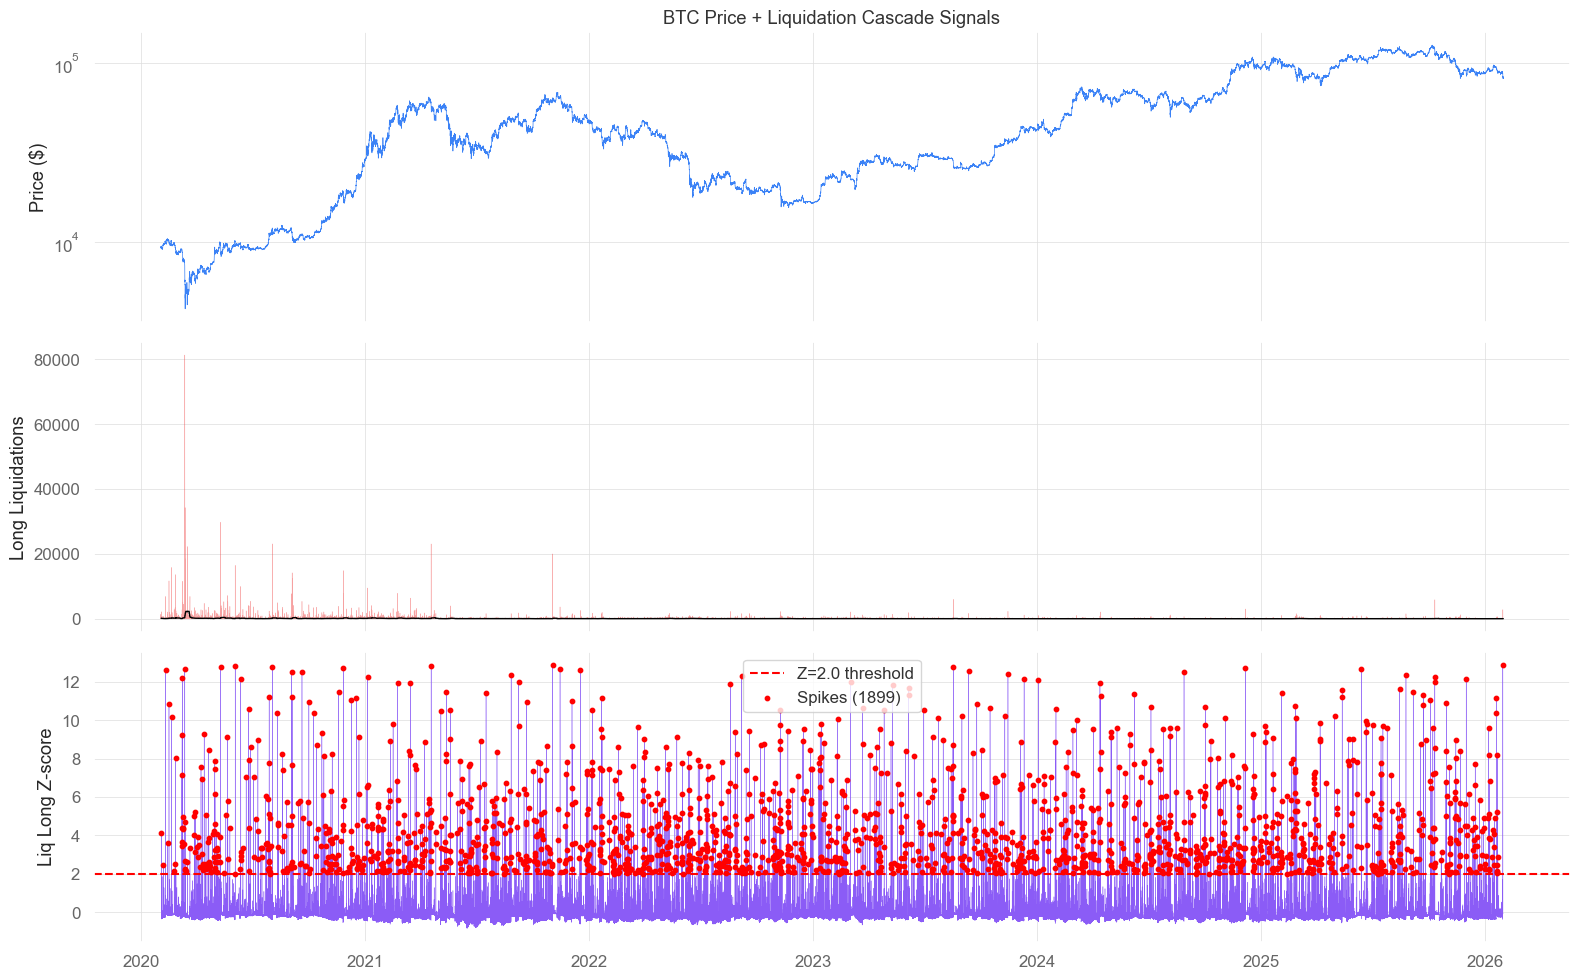

In [4]:
# Visualize liquidation spikes
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Price
axes[0].plot(df.index, df['price'], color='#3b82f6', linewidth=0.5)
axes[0].set_ylabel('Price ($)')
axes[0].set_title('BTC Price + Liquidation Cascade Signals')
axes[0].set_yscale('log')

# Long liquidations
axes[1].plot(df.index, df['liq_long'], color='#ef4444', linewidth=0.3, alpha=0.5)
axes[1].plot(df.index, df['liq_long_ma'], color='black', linewidth=1)
axes[1].set_ylabel('Long Liquidations')

# Z-score with threshold
axes[2].plot(df.index, df['liq_long_z'], color='#8b5cf6', linewidth=0.3)
axes[2].axhline(2.0, color='red', linestyle='--', label='Z=2.0 threshold')
spikes = df[df['liq_long_z'] > 2.0]
axes[2].scatter(spikes.index, spikes['liq_long_z'], color='red', s=10, zorder=5, label=f'Spikes ({len(spikes)})')
axes[2].set_ylabel('Liq Long Z-score')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Forward Returns After Liquidation Spikes

Before backtesting, check: does price actually bounce after liquidation cascades?

In [5]:
# Calculate forward returns at various horizons
for hrs in [1, 4, 8, 12, 24, 48, 72]:
    df[f'fwd_{hrs}h'] = df['price'].pct_change(hrs).shift(-hrs) * 100

# Compare forward returns: spike bars vs all bars
print('Forward returns after long liquidation spikes (Z > 2.0):')
print('=' * 90)
print(f'{"Horizon":>10s}  |  {"Spike Mean":>10s}  |  {"All Mean":>10s}  |  {"Diff":>8s}  |  {"Spike Win%":>10s}  |  {"N spikes":>8s}')
print('-' * 90)

spike_mask = df['liq_long_z'] > 2.0

for hrs in [1, 4, 8, 12, 24, 48, 72]:
    col = f'fwd_{hrs}h'
    spike_ret = df.loc[spike_mask, col].dropna()
    all_ret = df[col].dropna()
    
    spike_mean = spike_ret.mean()
    all_mean = all_ret.mean()
    diff = spike_mean - all_mean
    win_pct = (spike_ret > 0).mean() * 100
    
    print(f'{hrs:>8}h  |  {spike_mean:>+9.3f}%  |  {all_mean:>+9.3f}%  |  {diff:>+7.3f}%  |  {win_pct:>9.1f}%  |  {len(spike_ret):>8}')

Forward returns after long liquidation spikes (Z > 2.0):
   Horizon  |  Spike Mean  |    All Mean  |      Diff  |  Spike Win%  |  N spikes
------------------------------------------------------------------------------------------
       1h  |     -0.051%  |     +0.006%  |   -0.058%  |       51.2%  |      1899
       4h  |     -0.022%  |     +0.025%  |   -0.047%  |       51.2%  |      1899
       8h  |     -0.052%  |     +0.050%  |   -0.102%  |       51.6%  |      1899
      12h  |     -0.106%  |     +0.075%  |   -0.181%  |       49.4%  |      1899
      24h  |     +0.055%  |     +0.152%  |   -0.097%  |       52.7%  |      1898
      48h  |     +0.109%  |     +0.303%  |   -0.193%  |       52.4%  |      1898
      72h  |     +0.240%  |     +0.457%  |   -0.217%  |       52.7%  |      1898


In [6]:
# Same analysis for multiple Z thresholds
print('Mean forward return by Z-threshold and horizon:')
print('=' * 80)

horizons = [4, 12, 24, 48, 72]
print(f'{"Z-thresh":>10s}', end='')
for h in horizons:
    print(f'  |  {h:>5}h', end='')
print(f'  |  {"N":>5}')
print('-' * 80)

for z_thresh in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    mask = df['liq_long_z'] > z_thresh
    n = mask.sum()
    print(f'{z_thresh:>10.1f}', end='')
    for h in horizons:
        col = f'fwd_{h}h'
        ret = df.loc[mask, col].mean()
        print(f'  |  {ret:>+5.2f}%', end='')
    print(f'  |  {n:>5}')

Mean forward return by Z-threshold and horizon:
  Z-thresh  |      4h  |     12h  |     24h  |     48h  |     72h  |      N
--------------------------------------------------------------------------------
       1.0  |  +0.00%  |  -0.03%  |  +0.14%  |  +0.13%  |  +0.28%  |   3361
       1.5  |  +0.00%  |  -0.05%  |  +0.13%  |  +0.16%  |  +0.33%  |   2447
       2.0  |  -0.02%  |  -0.11%  |  +0.05%  |  +0.11%  |  +0.24%  |   1899
       2.5  |  -0.02%  |  -0.13%  |  -0.03%  |  +0.04%  |  +0.21%  |   1507
       3.0  |  -0.06%  |  -0.14%  |  -0.06%  |  +0.02%  |  +0.16%  |   1182
       4.0  |  -0.06%  |  -0.15%  |  -0.09%  |  -0.17%  |  +0.00%  |    823


## 4. VectorBT Backtest — Grid Search

Test combinations of:
- Z-threshold: 1.5, 2.0, 2.5, 3.0
- Take profit: 2%, 3%, 5%
- Stop loss: -2%, -3%, -5%
- Time stop: 24h, 48h, 72h

In [7]:
def run_liq_cascade_backtest(df, z_thresh, tp_pct, sl_pct, time_stop_hrs):
    """Backtest liquidation cascade scalper with given parameters.
    
    Entry: liq_long z-score > z_thresh
    Exit: first of take-profit, stop-loss, or time stop
    """
    price = df['price'].copy()
    entries = (df['liq_long_z'] > z_thresh).copy()
    
    # Debounce: don't re-enter within time_stop_hrs after an entry
    entry_idx = entries[entries].index
    debounced = pd.Series(False, index=entries.index)
    last_entry = pd.Timestamp('1970-01-01')
    for ts in entry_idx:
        if (ts - last_entry) >= pd.Timedelta(hours=time_stop_hrs):
            debounced.loc[ts] = True
            last_entry = ts
    entries = debounced
    
    if entries.sum() == 0:
        return None
    
    pf = vbt.Portfolio.from_signals(
        close=price,
        entries=entries,
        exits=False,  # Use sl/tp stops
        fees=0.001,
        slippage=0.001,
        init_cash=10_000,
        freq='1h',
        tp_stop=tp_pct / 100,
        sl_stop=sl_pct / 100,
    )
    
    n_trades = pf.trades.count()
    if n_trades == 0:
        return None
    
    return {
        'z_thresh': z_thresh,
        'tp_pct': tp_pct,
        'sl_pct': sl_pct,
        'time_stop': time_stop_hrs,
        'total_return': pf.total_return() * 100,
        'sharpe': pf.sharpe_ratio(),
        'max_dd': pf.max_drawdown() * 100,
        'n_trades': n_trades,
        'win_rate': pf.trades.win_rate() * 100,
        'avg_trade': pf.trades.returns.mean() * 100,
        'profit_factor': pf.trades.profit_factor() if hasattr(pf.trades, 'profit_factor') else np.nan,
        'portfolio': pf,
    }


# Grid search
z_thresholds = [1.5, 2.0, 2.5, 3.0]
tp_levels = [2, 3, 5]
sl_levels = [2, 3, 5]
time_stops = [24, 48, 72]

grid_results = []
total_combos = len(z_thresholds) * len(tp_levels) * len(sl_levels) * len(time_stops)
print(f'Running {total_combos} parameter combinations...')

for z, tp, sl, ts in product(z_thresholds, tp_levels, sl_levels, time_stops):
    r = run_liq_cascade_backtest(df, z, tp, sl, ts)
    if r is not None:
        grid_results.append(r)

print(f'Completed: {len(grid_results)} valid results out of {total_combos} combos')

Running 108 parameter combinations...


Completed: 108 valid results out of 108 combos


In [8]:
# Results table — top 20 by Sharpe
grid_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'portfolio'} for r in grid_results])
grid_df = grid_df.sort_values('sharpe', ascending=False)

print('Top 20 configurations by Sharpe ratio:')
print('=' * 130)
print(f'{"Z":>4s}  {"TP%":>4s}  {"SL%":>4s}  {"TimeStop":>8s}  |  {"Return":>9s}  {"Sharpe":>7s}  {"MaxDD":>8s}  {"Trades":>7s}  {"WinRate":>8s}  {"AvgTrade":>9s}  {"PF":>6s}')
print('-' * 130)

for _, row in grid_df.head(20).iterrows():
    pf_val = row.get('profit_factor', np.nan)
    pf_str = f'{pf_val:.2f}' if not np.isnan(pf_val) else 'N/A'
    print(f'{row["z_thresh"]:>4.1f}  {row["tp_pct"]:>4.0f}  {row["sl_pct"]:>4.0f}  {row["time_stop"]:>6.0f}h  |  '
          f'{row["total_return"]:>+8.1f}%  {row["sharpe"]:>7.2f}  {row["max_dd"]:>7.1f}%  '
          f'{row["n_trades"]:>7.0f}  {row["win_rate"]:>7.1f}%  {row["avg_trade"]:>+8.2f}%  {pf_str:>6s}')

Top 20 configurations by Sharpe ratio:
   Z   TP%   SL%  TimeStop  |     Return   Sharpe     MaxDD   Trades   WinRate   AvgTrade      PF
----------------------------------------------------------------------------------------------------------------------------------
 1.5     5     3      72h  |     +88.4%     0.48    -51.0%      351     45.0%     +0.29%    1.06
 3.0     5     3      72h  |     +77.2%     0.46    -49.0%      292     45.9%     +0.30%    1.07
 2.0     5     3      72h  |     +67.1%     0.42    -63.0%      338     44.7%     +0.26%    1.05
 2.0     5     3      48h  |     +61.2%     0.40    -50.8%      377     45.1%     +0.24%    1.04
 2.0     5     5      72h  |     +43.6%     0.35    -71.6%      284     55.6%     +0.30%    1.04
 1.5     3     3      72h  |     +34.9%     0.32    -57.5%      411     56.4%     +0.14%    1.02
 1.5     5     3      24h  |     +12.4%     0.25    -68.0%      459     43.8%     +0.13%    1.01
 2.5     5     3      24h  |     +11.0%     0.24    -

## 5. Best Configuration Deep Dive

In [9]:
# Pick the best by Sharpe
best = max(grid_results, key=lambda r: r['sharpe'] if r['sharpe'] == r['sharpe'] else -999)
pf_best = best['portfolio']

print(f'Best configuration:')
print(f'  Z-threshold: {best["z_thresh"]}')
print(f'  Take profit: {best["tp_pct"]}%')
print(f'  Stop loss:   {best["sl_pct"]}%')
print(f'  Time stop:   {best["time_stop"]}h')
print(f'\nPerformance:')
print(f'  Total return: {best["total_return"]:+.1f}%')
print(f'  Sharpe ratio: {best["sharpe"]:.2f}')
print(f'  Max drawdown: {best["max_dd"]:.1f}%')
print(f'  Trades:       {best["n_trades"]}')
print(f'  Win rate:     {best["win_rate"]:.1f}%')
print(f'  Avg trade:    {best["avg_trade"]:+.2f}%')

# Trade log
trades = pf_best.trades.records_readable
if len(trades) > 0:
    print(f'\nTrade log (first 20):')
    cols = [c for c in ['Entry Timestamp', 'Exit Timestamp', 'PnL', 'Return', 'Status'] if c in trades.columns]
    print(trades[cols].head(20).to_string())

Best configuration:
  Z-threshold: 1.5
  Take profit: 5%
  Stop loss:   3%
  Time stop:   72h

Performance:
  Total return: +88.4%
  Sharpe ratio: 0.48
  Max drawdown: -51.0%
  Trades:       351
  Win rate:     45.0%
  Avg trade:    +0.29%

Trade log (first 20):
       Entry Timestamp      Exit Timestamp         PnL    Return  Status
0  2020-02-03 02:00:00 2020-02-08 15:00:00  490.367067  0.049086  Closed
1  2020-02-10 05:00:00 2020-02-13 05:00:00  513.076483  0.048958  Closed
2  2020-02-13 08:00:00 2020-02-15 16:00:00 -382.729216 -0.034817  Closed
3  2020-02-16 16:00:00 2020-02-25 13:00:00 -416.183754 -0.039225  Closed
4  2020-03-07 16:00:00 2020-03-08 12:00:00 -339.178772 -0.033271  Closed
5  2020-03-12 10:00:00 2020-03-12 19:00:00 -479.135652 -0.048616  Closed
6  2020-03-16 10:00:00 2020-03-16 12:00:00  532.232735  0.056760  Closed
7  2020-03-20 20:00:00 2020-03-21 08:00:00 -393.054124 -0.039668  Closed
8  2020-03-25 10:00:00 2020-03-27 23:00:00 -347.495496 -0.036517  Closed
9  2020

## 6. Equity Curve & Drawdown

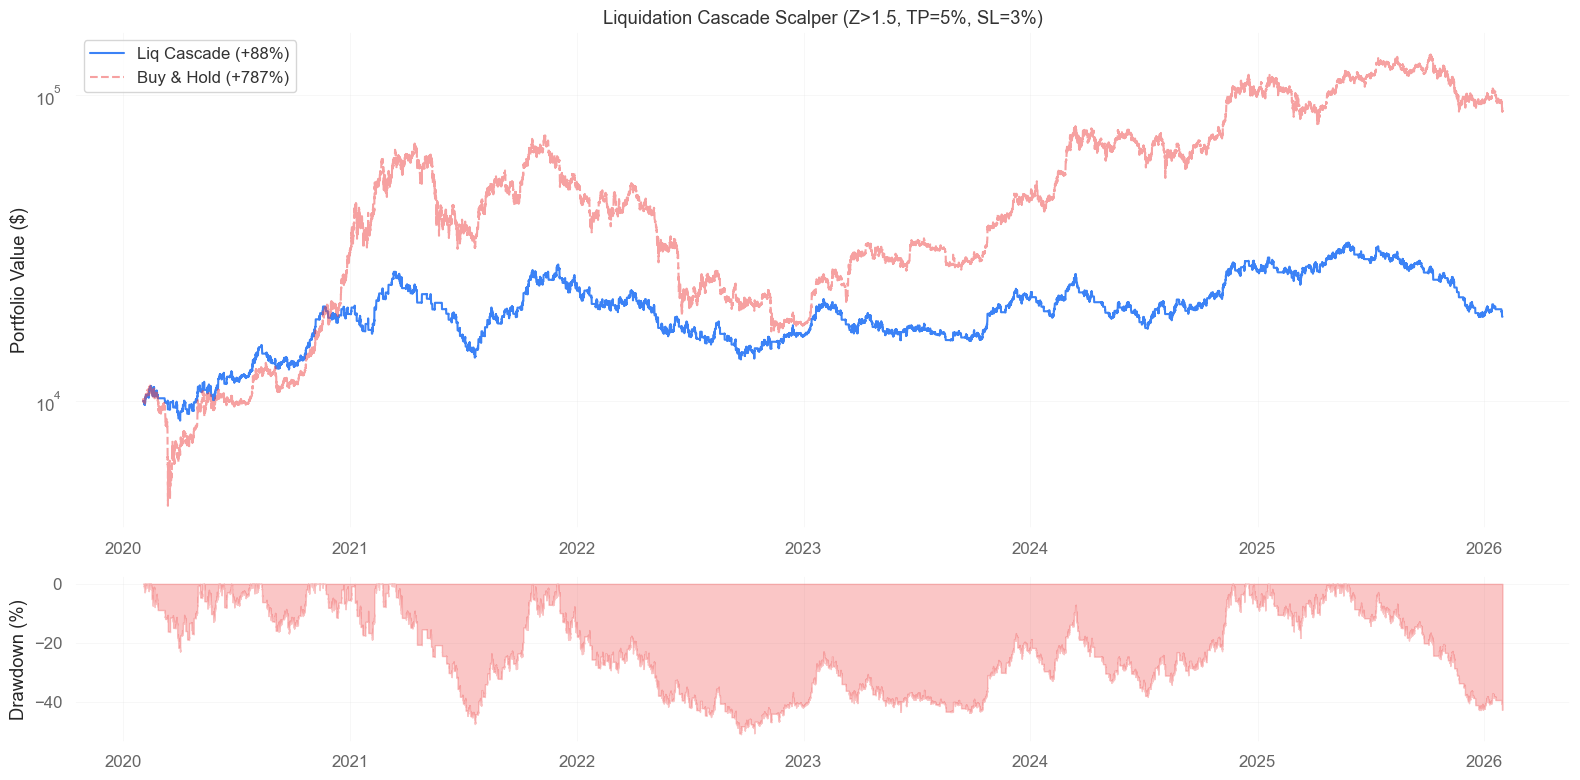

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

# Equity
equity = pf_best.value()
bh = 10_000 * df['price'] / df['price'].iloc[0]

axes[0].plot(equity.index, equity.values, color='#3b82f6', label=f'Liq Cascade ({best["total_return"]:+.0f}%)')
axes[0].plot(bh.index, bh.values, color='#ef4444', linestyle='--', alpha=0.5, label=f'Buy & Hold ({(bh.iloc[-1]/10000-1)*100:+.0f}%)')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title(f'Liquidation Cascade Scalper (Z>{best["z_thresh"]}, TP={best["tp_pct"]}%, SL={best["sl_pct"]}%)')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Drawdown
dd = pf_best.drawdown()
axes[1].fill_between(dd.index, dd.values * 100, 0, color='#ef4444', alpha=0.3)
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Year-by-Year Breakdown

In [11]:
# Annual returns
equity = pf_best.value()
annual = equity.resample('YE').last()
annual_ret = annual.pct_change().dropna() * 100

print('Year-by-year returns:')
print('=' * 40)
for date, ret in annual_ret.items():
    print(f'  {date.year}: {ret:>+8.1f}%')

# Monthly win rate
if len(trades) > 0:
    print(f'\nOverall stats:')
    print(f'  Total trades: {len(trades)}')
    winners = trades[trades['PnL'] > 0] if 'PnL' in trades.columns else pd.DataFrame()
    losers = trades[trades['PnL'] <= 0] if 'PnL' in trades.columns else pd.DataFrame()
    if len(winners) > 0 and len(losers) > 0:
        print(f'  Winners: {len(winners)} ({len(winners)/len(trades)*100:.1f}%)')
        print(f'  Losers:  {len(losers)} ({len(losers)/len(trades)*100:.1f}%)')
        print(f'  Avg win:  {winners["Return"].mean()*100:+.2f}%')
        print(f'  Avg loss: {losers["Return"].mean()*100:+.2f}%')

Year-by-year returns:
  2021:    +19.1%
  2022:    -28.9%
  2023:    +33.6%
  2024:    +21.6%
  2025:    -28.2%
  2026:     -0.8%

Overall stats:
  Total trades: 351
  Winners: 158 (45.0%)
  Losers:  193 (55.0%)
  Avg win:  +5.40%
  Avg loss: -3.89%


## 8. Key Findings

In [12]:
print('=' * 70)
print('LIQUIDATION CASCADE SCALPER — KEY FINDINGS')
print('=' * 70)

print(f'\n1. FORWARD RETURNS AFTER CASCADES:')
spike_mask = df['liq_long_z'] > 2.0
for h in [4, 24, 48]:
    col = f'fwd_{h}h'
    spike_mean = df.loc[spike_mask, col].mean()
    all_mean = df[col].mean()
    print(f'   {h}h: spike={spike_mean:+.3f}% vs all={all_mean:+.3f}% (diff={spike_mean-all_mean:+.3f}%)')

print(f'\n2. BEST CONFIGURATION:')
print(f'   Z>{best["z_thresh"]}, TP={best["tp_pct"]}%, SL={best["sl_pct"]}%, Time={best["time_stop"]}h')
print(f'   Return: {best["total_return"]:+.1f}% | Sharpe: {best["sharpe"]:.2f} | MaxDD: {best["max_dd"]:.1f}%')
print(f'   Trades: {best["n_trades"]} | Win rate: {best["win_rate"]:.1f}%')

print(f'\n3. GRID SEARCH SUMMARY:')
print(f'   Valid configs: {len(grid_results)}/{total_combos}')
sharpes = [r['sharpe'] for r in grid_results if r['sharpe'] == r['sharpe']]
profitable = [r for r in grid_results if r['total_return'] > 0]
print(f'   Profitable configs: {len(profitable)}/{len(grid_results)}')
print(f'   Sharpe range: {min(sharpes):.2f} to {max(sharpes):.2f}')

bh_ret = (df['price'].iloc[-1] / df['price'].iloc[0] - 1) * 100
beat_bh = [r for r in grid_results if r['total_return'] > bh_ret]
print(f'   Configs beating B&H ({bh_ret:+.0f}%): {len(beat_bh)}/{len(grid_results)}')

print(f'\n4. VERDICT:')
if best['sharpe'] > 1.0 and best['win_rate'] > 55:
    print('   Strategy shows promise — liquidation cascades provide tradeable bounces.')
    print('   Consider paper trading with the best configuration.')
elif best['sharpe'] > 0.5:
    print('   Marginal edge detected — cascades provide a small mean-reversion signal.')
    print('   Not strong enough for standalone trading. Could work as a filter.')
else:
    print('   Weak or no edge — liquidation cascades alone are not a reliable entry signal.')
    print('   The bounce is either too small or too inconsistent to trade profitably.')

print('\n' + '=' * 70)

LIQUIDATION CASCADE SCALPER — KEY FINDINGS

1. FORWARD RETURNS AFTER CASCADES:
   4h: spike=-0.022% vs all=+0.025% (diff=-0.047%)
   24h: spike=+0.055% vs all=+0.152% (diff=-0.097%)
   48h: spike=+0.109% vs all=+0.303% (diff=-0.193%)

2. BEST CONFIGURATION:
   Z>1.5, TP=5%, SL=3%, Time=72h
   Return: +88.4% | Sharpe: 0.48 | MaxDD: -51.0%
   Trades: 351 | Win rate: 45.0%

3. GRID SEARCH SUMMARY:
   Valid configs: 108/108
   Profitable configs: 14/108
   Sharpe range: -1.25 to 0.48
   Configs beating B&H (+787%): 0/108

4. VERDICT:
   Weak or no edge — liquidation cascades alone are not a reliable entry signal.
   The bounce is either too small or too inconsistent to trade profitably.

